In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
from procompa import get_project_root, get_data_dir

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
data_dir_YM = get_data_dir() / "26.03_yeast.MAP"

for whcih complexes does Ym add sth? (check that i kept highest jacard index), does that make senese- function and iptm score? also what is the prop score between the added proteins

In [2]:
Ym_compl_overlap = pl.read_csv( data_dir/ "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv")

In [ ]:
additional_prot = Ym_compl_overlap.filter(pl.col("size_pred")>pl.col("size_true")).with_columns(
    size_diff = pl.col("size_pred") - pl.col("size_true")
) 


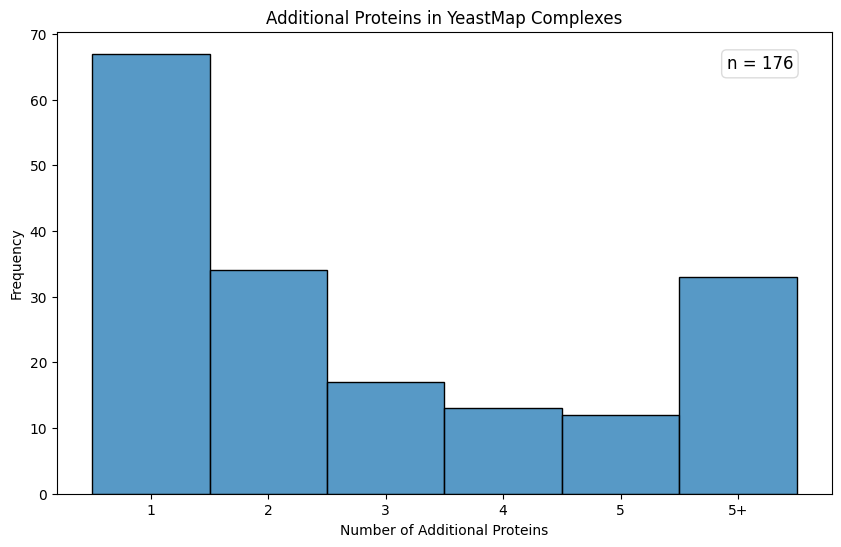

In [13]:
# 1. Cap data and calculate the total number of complexes (n)
plot_data = additional_prot["size_diff"].clip(upper_bound=6)
n_complexes = len(additional_prot)  # Gets total row count

plt.figure(figsize=(10, 6))

# Capture the axes object (ax) from the histplot
ax = sns.histplot(plot_data, discrete=True)

plt.title("Additional Proteins in YeastMap Complexes")
plt.xlabel("Number of Additional Proteins")
plt.ylabel("Frequency")
plt.xticks(ticks=range(1, 7), labels=['1', '2', '3', '4', '5', '5+'])


ax.text(
    x=0.95, 
    y=0.95, 
    s=f"n = {n_complexes:,}",  # Formats with commas if n is large
    transform=ax.transAxes, 
    horizontalalignment='right', 
    verticalalignment='top',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8)
)

plt.show()

In [3]:
#ccompletely new predictions
new_ym_predictions = Ym_compl_overlap.filter(pl.col("match_count") == 0)